In [1]:
# ============================================================================
# CELLULE 1 : MONTER GOOGLE DRIVE
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================================
# CELLULE 2 : CONFIGURATION DES CHEMINS
# ============================================================================
# ⚠️ VOUS DEVEZ ADAPTER CES CHEMINS selon l'emplacement de vos fichiers dans Drive

# Chemins vers vos datasets dans Google Drive
# Exemple : si vos fichiers sont dans "Mon Drive / NOC_Project / data /"
DRIVE_TRAIN_FILE = "/content/drive/MyDrive/breakdown-dataset/Dataset/train_dataset.jsonl"
DRIVE_VAL_FILE   = "/content/drive/MyDrive/breakdown-dataset/Dataset/val_dataset.jsonl"
DRIVE_TEST_FILE  = "/content/drive/MyDrive/breakdown-dataset/Dataset/test_dataset.jsonl"

# Dossier où sera sauvegardé le modèle fine-tuné (sera créé automatiquement)
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/breakdown-dataset/NOC_Project/netbert_noc_finetuned"

# Dossier local temporaire dans Colab (plus rapide pour l'entraînement)
LOCAL_TRAIN_FILE = "/content/train_dataset.jsonl"
LOCAL_VAL_FILE   = "/content/val_dataset.jsonl"
LOCAL_TEST_FILE  = "/content/test_dataset.jsonl"
LOCAL_MODEL_DIR  = "/content/netbert_base"
LOCAL_OUTPUT_DIR = "/content/finetuned_model"

print("✅ Chemins configurés.")
print(f"   Train : {DRIVE_TRAIN_FILE}")
print(f"   Val   : {DRIVE_VAL_FILE}")
print(f"   Test  : {DRIVE_TEST_FILE}")
print(f"   Sortie: {DRIVE_OUTPUT_DIR}")



✅ Chemins configurés.
   Train : /content/drive/MyDrive/breakdown-dataset/Dataset/train_dataset.jsonl
   Val   : /content/drive/MyDrive/breakdown-dataset/Dataset/val_dataset.jsonl
   Test  : /content/drive/MyDrive/breakdown-dataset/Dataset/test_dataset.jsonl
   Sortie: /content/drive/MyDrive/breakdown-dataset/NOC_Project/netbert_noc_finetuned


In [3]:
# ============================================================================
# CELLULE 3 : COPIER LES FICHIERS VERS LE DISQUE LOCAL COLAB
# ============================================================================

import shutil
import os

print("📂 Copie des datasets vers le disque local...")

shutil.copy(DRIVE_TRAIN_FILE, LOCAL_TRAIN_FILE)
shutil.copy(DRIVE_VAL_FILE, LOCAL_VAL_FILE)
shutil.copy(DRIVE_TEST_FILE, LOCAL_TEST_FILE)

print("✅ Fichiers copiés localement.")

📂 Copie des datasets vers le disque local...
✅ Fichiers copiés localement.


In [4]:
# ============================================================================
# CELLULE 4 : TÉLÉCHARGEMENT DE NetBERT
# ============================================================================
# On télécharge NetBERT directement depuis Hugging Face

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# MODEL_NAME = "antoinelouis/netbert"
MODEL_NAME = "microsoft/deberta-v3-large"

print(f"📥 Téléchargement du tokenizer depuis {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"📥 Téléchargement du modèle NetBERT...")
# Pour l'instant, on le charge sans tête de classification
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Sauvegarder localement pour pouvoir le réutiliser
print(f"💾 Sauvegarde locale dans {LOCAL_MODEL_DIR}...")
tokenizer.save_pretrained(LOCAL_MODEL_DIR)
model.save_pretrained(LOCAL_MODEL_DIR)

print("✅ NetBERT téléchargé et sauvegardé localement !")

📥 Téléchargement du tokenizer depuis microsoft/deberta-v3-large...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias         

💾 Sauvegarde locale dans /content/netbert_base...


model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ NetBERT téléchargé et sauvegardé localement !


In [5]:
# ============================================================================
# CELLULE 5 : INSTALLATION DES DÉPENDANCES
# ============================================================================

!pip install -q datasets evaluate scikit-learn

print("✅ Dépendances installées.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 490.6 kB/s eta 0:00:00
✅ Dépendances installées.


In [6]:
# ============================================================================
# CELLULE 6 : CHARGEMENT DES DONNÉES
# ============================================================================

import json
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict
from collections import Counter

def load_jsonl(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line.strip()))
    return data

def extract_input_and_cause(data):
    inputs = []
    causes = []
    for item in data:
        input_text = item['input'].strip()
        full_output = item['output']
        parts = full_output.split('|')
        cause = parts[-1].strip()
        inputs.append(input_text)
        causes.append(cause)
    return inputs, causes

print("📂 Chargement des fichiers JSONL...")

train_raw = load_jsonl(LOCAL_TRAIN_FILE)
val_raw   = load_jsonl(LOCAL_VAL_FILE)
test_raw  = load_jsonl(LOCAL_TEST_FILE)

print(f"   Train : {len(train_raw)} exemples")
print(f"   Val   : {len(val_raw)} exemples")
print(f"   Test  : {len(test_raw)} exemples")

train_inputs, train_causes = extract_input_and_cause(train_raw)
val_inputs, val_causes     = extract_input_and_cause(val_raw)
test_inputs, test_causes   = extract_input_and_cause(test_raw)

all_causes = sorted(list(set(train_causes + val_causes + test_causes)))
print(f"\n📊 {len(all_causes)} causes uniques trouvées.")

id2label = {i: label for i, label in enumerate(all_causes)}
label2id = {label: i for i, label in enumerate(all_causes)}

train_labels = [label2id[c] for c in train_causes]
val_labels   = [label2id[c] for c in val_causes]
test_labels  = [label2id[c] for c in test_causes]

train_df = pd.DataFrame({'text': train_inputs, 'label': train_labels})
val_df   = pd.DataFrame({'text': val_inputs,   'label': val_labels})
test_df  = pd.DataFrame({'text': test_inputs,  'label': test_labels})

train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

print(f"\n✅ Données préparées :")
print(f"   Train      : {len(train_dataset)} exemples")
print(f"   Validation : {len(val_dataset)} exemples")
print(f"   Test       : {len(test_dataset)} exemples")

📂 Chargement des fichiers JSONL...
   Train : 298 exemples
   Val   : 40 exemples
   Test  : 40 exemples

📊 21 causes uniques trouvées.

✅ Données préparées :
   Train      : 298 exemples
   Validation : 40 exemples
   Test       : 40 exemples


In [7]:
# ============================================================================
# CELLULE 7 : VÉRIFICATION DE L'EXTRACTION ET DISTRIBUTION
# ============================================================================

print("="*60)
print("📊 DISTRIBUTION DES CAUSES DANS LE TRAINSET")
print("="*60)

train_causes_count = Counter(train_causes)
for cause, count in train_causes_count.most_common():
    pct = count / len(train_causes) * 100
    bar = "█" * int(pct / 2) if pct > 5 else "░" * 5
    print(f"   {cause:<45} {count:3d} ({pct:5.1f}%) {bar}")

most_common_pct = train_causes_count.most_common(1)[0][1] / len(train_causes) * 100
if most_common_pct > 50:
    print(f"\n❌ PROBLÈME : Une classe représente {most_common_pct:.1f}% des données !")
else:
    print(f"\n✅ La distribution est acceptable.")

📊 DISTRIBUTION DES CAUSES DANS LE TRAINSET
   Coupure ENEO & Baisse de tension               15 (  5.0%) ██
   AKTIVCO Coupure ENEO & Baisse de tension       15 (  5.0%) ██
   Default GE & Power Cabinet                     15 (  5.0%) ██
   AKTIVCO Defaut GE & Power Cabinet              15 (  5.0%) ██
   MPR issue                                      15 (  5.0%) ██
   Sites strategiques, MLL, Pylone, etc.          15 (  5.0%) ██
   Sharing                                        15 (  5.0%) ██
   Sites strategiques & DataCenter                15 (  5.0%) ██
   SAT                                            15 (  5.0%) ██
   SPARE-ISSUE                                    15 (  5.0%) ██
   EXCLU                                          15 (  5.0%) ██
   Fiber AOF                                      15 (  5.0%) ██
   ACCESS-ISSUE                                   15 (  5.0%) ██
   Projet OCM (ZTE, NOKIA, autres projets)        15 (  5.0%) ██
   Projet OCM (NOKIA)                          

In [8]:
# ============================================================================
# CELLULE 8 : TOKENIZATION
# ============================================================================

def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,
        max_length=512
    )

print("🔄 Tokenization des données...")

tokenized_dataset = dataset_dict.map(
    preprocess_function,
    batched=True,
    remove_columns=["text"]
)

print("✅ Tokenization terminée.")

🔄 Tokenization des données...


Map:   0%|          | 0/298 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

✅ Tokenization terminée.


In [9]:
# ============================================================================
# CELLULE 9 : MODÈLE AVEC RÉINITIALISATION COMPLÈTE
# ============================================================================

import torch
from transformers import AutoModelForSequenceClassification

print("📥 Rechargement du modèle avec tête de classification...")

model = AutoModelForSequenceClassification.from_pretrained(
    LOCAL_MODEL_DIR,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("\n🔄 Réinitialisation de la tête de classification...")
model.classifier = torch.nn.Linear(model.config.hidden_size, len(id2label))
model.classifier.weight.data.normal_(mean=0.0, std=0.02)
model.classifier.bias.data.zero_()

print("\n🔓 Configuration des paramètres entraînables...")

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

for name, param in model.base_model.named_parameters():
    if "pooler" in name:
        param.requires_grad = True
    if "encoder.layer.9" in name or "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"   Paramètres entraînables : {trainable_params:,}")
print(f"   Paramètres totaux       : {total_params:,}")
print(f"   Pourcentage entraînable : {100*trainable_params/total_params:.2f}%")

print("✅ Modèle prêt !")

📥 Rechargement du modèle avec tête de classification...


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: /content/netbert_base
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 1024]) vs model:torch.Size([21, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([21])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



🔄 Réinitialisation de la tête de classification...

🔓 Configuration des paramètres entraînables...
   Paramètres entraînables : 37,810,197
   Paramètres totaux       : 435,083,285
   Pourcentage entraînable : 8.69%
✅ Modèle prêt !


In [10]:
# ============================================================================
# CELLULE 10 : CONFIGURATION DES MÉTRIQUES
# ============================================================================

import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predicted_classes = np.argmax(predictions, axis=1)

    acc = accuracy_metric.compute(predictions=predicted_classes, references=labels)['accuracy']
    f1_weighted = f1_metric.compute(predictions=predicted_classes, references=labels, average='weighted')['f1']
    f1_macro = f1_metric.compute(predictions=predicted_classes, references=labels, average='macro')['f1']

    return {
        'accuracy': round(acc, 4),
        'f1_weighted': round(f1_weighted, 4),
        'f1_macro': round(f1_macro, 4)
    }

print("✅ Métriques configurées.")

✅ Métriques configurées.


In [11]:
# ============================================================================
# CELLULE 11 : CONFIGURATION DE L'ENTRAÎNEMENT (VERSION QUI MARCHE)
# ============================================================================

from transformers import TrainingArguments, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=LOCAL_OUTPUT_DIR,
    learning_rate=2e-5,                     # ✅ Retour à 2e-5
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=20,                    # ✅ Retour à 30 époques
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    push_to_hub=False,
    report_to="none",
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
)

print("✅ Configuration (version qui marche) :")
print(f"   Learning rate : 2e-5")
print(f"   Époques : 30")
print(f"   Batch size : 8 (effectif 16)")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Configuration (version qui marche) :
   Learning rate : 2e-5
   Époques : 30
   Batch size : 8 (effectif 16)


In [18]:
# ============================================================================
# CELLULE 12 : ENTRAÎNEMENT (SANS PONDÉRATION)
# ============================================================================

from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

print("\n" + "="*60)
print("🏋️ DÉBUT DE L'ENTRAÎNEMENT (30 ÉPOQUES MAX)")
print("="*60)
print("\n⚠️ Surveillez la 'eval_loss' : elle doit DIMINUER")
print("="*60 + "\n")

trainer.train()

print("\n✅ Entraînement terminé !")

# Résumé
print("\n" + "="*60)
print("📊 RÉSUMÉ DE L'ENTRAÎNEMENT")
print("="*60)

for log in trainer.state.log_history[-5:]:
    if 'eval_loss' in log:
        epoch = log.get('epoch', '?')
        loss = log.get('loss', '?')
        eval_loss = log.get('eval_loss', '?')
        accuracy = log.get('eval_accuracy', '?')

        epoch_str = f"{float(epoch):.1f}" if isinstance(epoch, (int, float)) else str(epoch)
        loss_str = f"{float(loss):.4f}" if isinstance(loss, (int, float)) else str(loss)
        eval_loss_str = f"{float(eval_loss):.4f}" if isinstance(eval_loss, (int, float)) else str(eval_loss)
        acc_str = f"{float(accuracy):.4f}" if isinstance(accuracy, (int, float)) else str(accuracy)

        print(f"Epoch {epoch_str}: loss={loss_str}, eval_loss={eval_loss_str}, accuracy={acc_str}")


🏋️ DÉBUT DE L'ENTRAÎNEMENT (30 ÉPOQUES MAX)

⚠️ Surveillez la 'eval_loss' : elle doit DIMINUER



Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,6.079870,3.012137,0.050000,0.004800,0.004800
2,6.011390,3.010925,0.050000,0.004800,0.004800
3,6.038510,3.009584,0.050000,0.004800,0.004800
4,6.017868,3.008247,0.050000,0.004800,0.004800
5,6.007984,3.007236,0.050000,0.004800,0.004800
6,6.028217,3.006211,0.050000,0.004800,0.004800
7,6.052853,3.005690,0.050000,0.004800,0.004800
8,6.010899,3.004956,0.050000,0.004800,0.004800
9,6.020554,3.004276,0.050000,0.004800,0.004800
10,6.033344,3.003875,0.050000,0.004800,0.004800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


✅ Entraînement terminé !

📊 RÉSUMÉ DE L'ENTRAÎNEMENT
Epoch 20.0: loss=?, eval_loss=3.0026, accuracy=0.0500


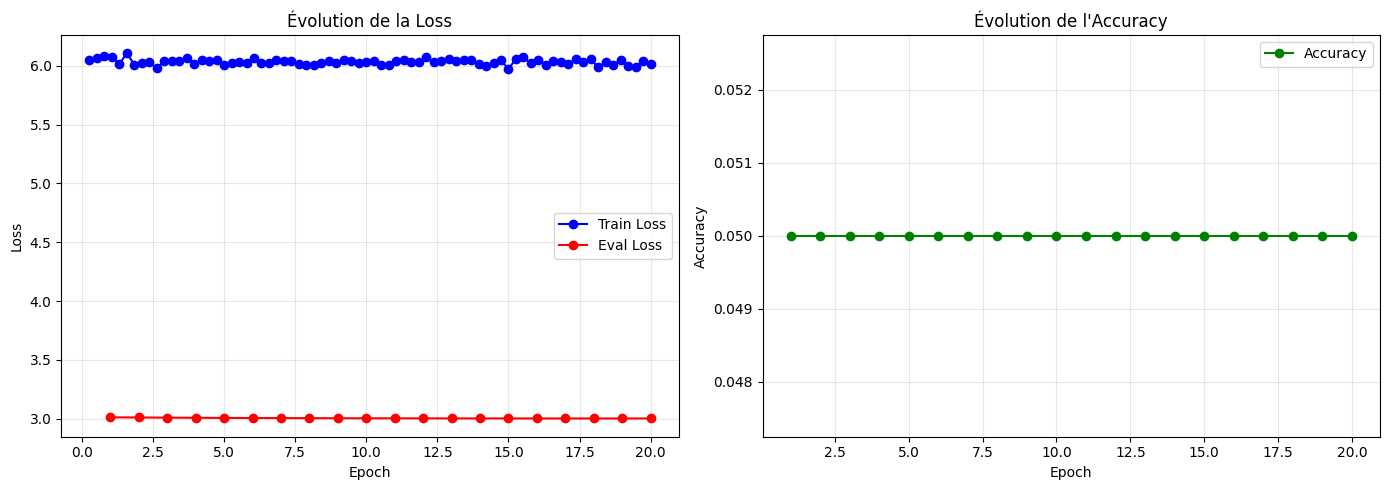

In [19]:
# ============================================================================
# CELLULE 13 : VISUALISATION DE LA LOSS
# ============================================================================

import matplotlib.pyplot as plt

train_losses, train_epochs = [], []
eval_losses, eval_epochs = [], []
eval_accuracies = []

for log in trainer.state.log_history:
    if 'loss' in log and 'epoch' in log:
        train_losses.append(log['loss'])
        train_epochs.append(log['epoch'])
    if 'eval_loss' in log and 'epoch' in log:
        eval_losses.append(log['eval_loss'])
        eval_epochs.append(log['epoch'])
        if 'eval_accuracy' in log:
            eval_accuracies.append(log['eval_accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_epochs, train_losses, 'b-o', label='Train Loss', markersize=6)
ax1.plot(eval_epochs, eval_losses, 'r-o', label='Eval Loss', markersize=6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Évolution de la Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

if eval_accuracies:
    ax2.plot(eval_epochs, eval_accuracies, 'g-o', label='Accuracy', markersize=6)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Évolution de l\'Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================================
# CELLULE 14 : ÉVALUATION FINALE SUR LE TEST SET (ROBUSTE)
# ============================================================================

print("\n" + "="*60)
print("📊 ÉVALUATION FINALE SUR LE TEST SET")
print("="*60)

try:
    # ---------------------------
    # PRÉDICTION
    # ---------------------------
    try:
        predictions = trainer.predict(tokenized_dataset["test"])
        logits = predictions.predictions
        labels = predictions.label_ids
        print("✅ Prédictions générées")
    except Exception as e:
        print("❌ Erreur pendant trainer.predict()")
        print(f"   Détail : {e}")
        raise

    # ---------------------------
    # ARGMAX
    # ---------------------------
    try:
        predicted_classes = np.argmax(logits, axis=1)
        print("✅ Argmax calculé")
    except Exception as e:
        print("❌ Erreur dans np.argmax")
        print(f"   Shape logits : {getattr(logits, 'shape', 'inconnu')}")
        print(f"   Détail : {e}")
        raise

    # ---------------------------
    # MÉTRIQUES
    # ---------------------------
    try:
        metrics = compute_metrics((logits, labels))
        print(f"\n📈 Métriques sur le test set :")
        for k, v in metrics.items():
            print(f"   {k}: {v}")
    except Exception as e:
        print("❌ Erreur dans compute_metrics")
        print(f"   Détail : {e}")
        raise

    # ---------------------------
    # AFFICHAGE EXEMPLES
    # ---------------------------
    print("\n📋 Exemples de prédictions :")
    print("-"*80)

    for i in range(min(10, len(test_inputs))):
        try:
            true_label = id2label[labels[i]]
            pred_label = id2label[predicted_classes[i]]
            status = "✅" if true_label == pred_label else "❌"

            print(f"\n{status} Exemple {i+1}")
            print(f"   Texte : {test_inputs[i][:80]}...")
            print(f"   Vrai  : {true_label}")
            print(f"   Prédit: {pred_label}")

        except KeyError as e:
            print(f"\n❌ Erreur mapping label à l’index {i}")
            print(f"   label brut: {labels[i]}")
            print(f"   prédiction brute: {predicted_classes[i]}")
            print(f"   Détail : {e}")

        except Exception as e:
            print(f"\n❌ Erreur inattendue à l’index {i}")
            print(f"   Détail : {e}")

except Exception as e:
    print("\n🚨 ERREUR GLOBALE DANS L'ÉVALUATION")
    print(f"   {e}")


📊 ÉVALUATION FINALE SUR LE TEST SET


✅ Prédictions générées
✅ Argmax calculé

📈 Métriques sur le test set :
   accuracy: 0.05
   f1_weighted: 0.0048
   f1_macro: 0.0048

📋 Exemples de prédictions :
--------------------------------------------------------------------------------

❌ Exemple 1
   Texte : Owner: CAMUSAT | Topology: Grid-Hybrid-Gen | Comment: OCM team performing final ...
   Vrai  : Projet OCM (ZTE, NOKIA, autres projets)
   Prédit: ACCESS-ISSUE

❌ Exemple 2
   Texte : Owner: ESCO | Topology: Gen Only | Comment: week 14 swap activities underway...
   Vrai  : Projet OCM (ZTE, NOKIA, autres projets)
   Prédit: ACCESS-ISSUE

❌ Exemple 3
   Texte : Owner: CAMUSAT | Topology: Grid-Gen | Comment: NOKIA 5G integration phase 3 acti...
   Vrai  : Projet OCM (ZTE, NOKIA, autres projets)
   Prédit: ACCESS-ISSUE

❌ Exemple 4
   Texte : Owner: ESCO | Topology: Hybrid-Gen | Comment: NOKIA AirScale commissioning ongoi...
   Vrai  : Projet OCM (ZTE, NOKIA, autres projets)
   Prédit: ACCESS-ISSUE

❌ Exemple 5
   Texte : Owner:

In [21]:
# ============================================================================
# CELLULE 15 : TEST DIRECT AVEC LE MODÈLE EN MÉMOIRE (SANS RECHARGEMENT)
# ============================================================================

import torch
import numpy as np

print("="*70)
print("🧪 TEST DIRECT SUR VOS 20 EXEMPLES")
print("="*70)

# Utiliser le modèle DÉJÀ chargé en mémoire (trainer.model)
model.eval()

INSTRUCTION = "You are a NOC expert assistant. Analyze the field comment and site metadata step by step. Produce the following 4 fields respecting the closed list of allowed values: Cause | Sub RCA | Category | OCM Nomenclature"

test_cases = [
    "Owner: CAMUSAT | Topology: Grid-Hybrid-Gen | Comment: SWAP for Week 12 activities ongoing",
    "Owner: IHS | Topology: Medium Grid + GE | Comment: generator fault detected",
    "Owner: CAMUSAT | Topology: Grid-Gen | Comment: fiber AOF issue detected",
    "Owner: ESCO | Topology: Grid-Gen | Comment: access blocked by local authority",
    "Owner: CAMUSAT | Topology: Grid-Gen | Comment: FRGU card replacement and check and clean jumper",
    "Owner: CAMUSAT | Topology: Solar-Gen | Comment: no anomaly detected",
    "Owner: IHS | Topology: GridOnly | Comment: grid outage awaiting restoration",
    "Owner: ESCO | Topology: Grid-Gen-Lithium | Comment: AOF down on transmission link",
    "Owner: CAMUSAT | Topology: Solar-Gen | Comment: site vandalized - red zone",
    "Owner: IHS | Topology: Good Grid no GE - 8h | Comment: check and clean jumper on RRU",
    "Owner: CAMUSAT | Topology: Grid-Gen | Comment: VLAN configuration issue detected",
    "Owner: ESCO | Topology: Gen Only | Comment: project team on site",
    "Owner: IHS | Topology: Bad Grid + GE | Comment: unstable power with generator fault",
    "Owner: CAMUSAT | Topology: Grid-Gen | Comment: network loop resolved BOTX",
    "Owner: CAMUSAT | Topology: Hybrid-Gen | Comment: project team work in progress on site",
    "Owner: ESCO | Topology: GridOnly | Comment: waiting for site key holder",
    "Owner: IHS | Topology: Medium Grid + GE | Comment: GE failure and battery issue",
    "Owner: CAMUSAT | Topology: Grid-Gen-Lithium | Comment: fiber AOF DOWN",
    "Owner: CAMUSAT | Topology: Grid-Gen | Comment: project swap en cours",
    "Owner: ESCO | Topology: Hybrid Solar - S1 | Comment: repeated site down due to power issue",
    "Owner: IHS | Topology: Bad Grid + GE | Comment: fog and condensation causing electrical issues",
   "Owner: ESCO | Topology: Grid-Gen | Comment: snake presence reported in strategic site shelter",
   "Owner: MTN | Topology: MTN Sharing| Comment: rack space limitation on shared infrastructure",
   "Owner: MTN | Topology: MTN Sharing | Comment: multiple operators affected by site outage",
  "Owner: MTN | Topology: MTN Sharing| Comment: shared generator capacity insufficient",
]

def predict_cause_direct(input_text):
    full_text = f"{INSTRUCTION}\n{input_text}\n"
    inputs = tokenizer(full_text, truncation=True, padding=True, max_length=512, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class_id = torch.argmax(logits, dim=-1).item()
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        confidence = probabilities[0][predicted_class_id].item()

    return id2label[predicted_class_id], confidence

print("\n" + "="*70)
print("📊 RÉSULTATS DES PRÉDICTIONS")
print("="*70 + "\n")

for i, test_input in enumerate(test_cases, 1):
    predicted_cause, confidence = predict_cause_direct(test_input)
    comment_part = test_input.split("Comment:")[1].strip() if "Comment:" in test_input else test_input
    print(f"{'─'*70}")
    print(f"📌 TEST #{i:2d}")
    print(f"   Commentaire : {comment_part[:60]}...")
    print(f"   🎯 CAUSE PRÉDITE : {predicted_cause}")
    print(f"   📊 CONFIANCE     : {confidence*100:.1f}%")

print(f"\n{'═'*70}")
print("✅ TESTS TERMINÉS")
print(f"{'═'*70}")

# Tableau récapitulatif
print("\n" + "="*70)
print("📊 TABLEAU RÉCAPITULATIF")
print("="*70)
print(f"\n{'N°':<4} {'CAUSE PRÉDITE':<45} {'CONFIANCE':<10}")
print("-"*70)

for i, test_input in enumerate(test_cases, 1):
    predicted_cause, confidence = predict_cause_direct(test_input)
    print(f"{i:<4} {predicted_cause:<45} {confidence*100:.1f}%")
print("-"*70)

🧪 TEST DIRECT SUR VOS 20 EXEMPLES

📊 RÉSULTATS DES PRÉDICTIONS

──────────────────────────────────────────────────────────────────────
📌 TEST # 1
   Commentaire : SWAP for Week 12 activities ongoing...
   🎯 CAUSE PRÉDITE : ACCESS-ISSUE
   📊 CONFIANCE     : 5.6%
──────────────────────────────────────────────────────────────────────
📌 TEST # 2
   Commentaire : generator fault detected...
   🎯 CAUSE PRÉDITE : ACCESS-ISSUE
   📊 CONFIANCE     : 5.6%
──────────────────────────────────────────────────────────────────────
📌 TEST # 3
   Commentaire : fiber AOF issue detected...
   🎯 CAUSE PRÉDITE : ACCESS-ISSUE
   📊 CONFIANCE     : 5.6%
──────────────────────────────────────────────────────────────────────
📌 TEST # 4
   Commentaire : access blocked by local authority...
   🎯 CAUSE PRÉDITE : ACCESS-ISSUE
   📊 CONFIANCE     : 5.6%
──────────────────────────────────────────────────────────────────────
📌 TEST # 5
   Commentaire : FRGU card replacement and check and clean jumper...
   🎯 CAUSE PRÉDIT

In [22]:
# ============================================================================
# CELLULE 16 : SAUVEGARDE ET CRÉATION DU ZIP (CORRIGÉE)
# ============================================================================

import zipfile
import os
import shutil

print("\n💾 Sauvegarde du modèle fine-tuné...")

# 1. Sauvegarder le modèle et le tokenizer
trainer.save_model(LOCAL_OUTPUT_DIR)
tokenizer.save_pretrained(LOCAL_OUTPUT_DIR)

print(f"✅ Modèle sauvegardé dans : {LOCAL_OUTPUT_DIR}")

# 2. Supprimer tous les dossiers de checkpoints inutiles
print("\n🧹 Nettoyage des checkpoints...")
deleted = 0
for item in os.listdir(LOCAL_OUTPUT_DIR):
    item_path = os.path.join(LOCAL_OUTPUT_DIR, item)
    if item.startswith("checkpoint-") and os.path.isdir(item_path):
        shutil.rmtree(item_path)
        deleted += 1
        print(f"   Supprimé : {item}")
if deleted == 0:
    print("   Aucun dossier checkpoint trouvé.")
else:
    print(f"   ✅ {deleted} dossier(s) checkpoint supprimé(s).")

# 3. Vérifier les fichiers restants
print("\n📋 Fichiers conservés :")
for f in os.listdir(LOCAL_OUTPUT_DIR):
    print(f"   - {f}")

# 4. Créer l'archive ZIP (uniquement des fichiers, plus de dossiers lourds)
print("\n📦 Création de l'archive ZIP...")
zip_path = "/content/netbert_noc_finetuned.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(LOCAL_OUTPUT_DIR):
        # On ignore les dossiers (ne devrait plus y en avoir)
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, LOCAL_OUTPUT_DIR)
            zipf.write(file_path, arcname)

# 5. Vérifier que le ZIP a bien été créé
if os.path.exists(zip_path):
    zip_size = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"✅ Archive créée : {zip_path}")
    print(f"   Taille : {zip_size:.1f} Mo")
else:
    print("❌ ERREUR : L'archive n'a pas pu être créée.")


💾 Sauvegarde du modèle fine-tuné...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle sauvegardé dans : /content/finetuned_model

🧹 Nettoyage des checkpoints...
   Supprimé : checkpoint-323
   Supprimé : checkpoint-209
   Supprimé : checkpoint-228
   Supprimé : checkpoint-38
   Supprimé : checkpoint-114
   Supprimé : checkpoint-247
   Supprimé : checkpoint-133
   Supprimé : checkpoint-266
   Supprimé : checkpoint-361
   Supprimé : checkpoint-285
   Supprimé : checkpoint-190
   Supprimé : checkpoint-57
   Supprimé : checkpoint-95
   Supprimé : checkpoint-19
   Supprimé : checkpoint-171
   Supprimé : checkpoint-152
   Supprimé : checkpoint-380
   Supprimé : checkpoint-342
   Supprimé : checkpoint-76
   Supprimé : checkpoint-304
   ✅ 20 dossier(s) checkpoint supprimé(s).

📋 Fichiers conservés :
   - training_args.bin
   - model.safetensors
   - tokenizer.json
   - config.json
   - tokenizer_config.json

📦 Création de l'archive ZIP...


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# CELLULE 17 : TÉLÉCHARGEMENT DIRECT
# ============================================================================

from google.colab import files
import os

print("="*60)
print("📥 TÉLÉCHARGEMENT DU MODÈLE FINE-TUNÉ")
print("="*60)

zip_path = "/content/netbert_noc_finetuned.zip"

if os.path.exists(zip_path):
    zip_size = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"\n📦 Fichier : netbert_noc_finetuned.zip")
    print(f"📊 Taille : {zip_size:.1f} Mo")
    print("\n⏳ Téléchargement en cours...")
    files.download(zip_path)
    print("\n✅ Téléchargement lancé !")
else:
    print("\n❌ ERREUR : Le fichier ZIP n'existe pas !")
    print("   Vérifiez que la Cellule 16 a bien été exécutée.")